# Measured cycle-aging and early-cycle RUL benchmark

Built with [Vicena](https://vicena.ai). This notebook adds a second measured experimental program: 3.4 Ah lithium-sulfur pouch-cell cycle-aging summaries across temperature and charge/discharge-rate conditions. It predicts the cycle at which mean normalized capacity crosses 0.80 using only measurements through cycle 60.

In [1]:
from pathlib import Path
import sys,json
sys.path.insert(0,str(Path('..')/'src'))
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from battery_twin import load_lis_cycle_capacity,benchmark_rul
out=Path('../outputs'); out.mkdir(exist_ok=True)

In [2]:
d=load_lis_cycle_capacity('../datasets/measured/li_s_cycle_aging/VZ1_035_021_CVUT_D_0003_v1.txt')
r,m=benchmark_rul(d,early_cycles=60,threshold=.8)
print('Measured condition trajectories:',d.condition.nunique())
print('Measured summary rows:',len(d))
print('Cycle range:',int(d.cycle.min()),int(d.cycle.max()))
print(json.dumps(m,indent=2))
print('Boundary: condition-level published means, not raw individual-cell trajectories')
d.to_csv(out/'lis_cycle_capacity.csv',index=False); r.to_csv(out/'rul_benchmark.csv',index=False); (out/'rul_metrics.json').write_text(json.dumps(m,indent=2))

Measured condition trajectories: 10
Measured summary rows: 105
Cycle range: 0 400
{
  "exponential": {
    "n_conditions": 10,
    "mae_cycles": 9.262667789461693,
    "median_ae_cycles": 7.704488182457191
  },
  "linear": {
    "n_conditions": 10,
    "mae_cycles": 10.284887013984616,
    "median_ae_cycles": 8.282966522416071
  }
}
Boundary: condition-level published means, not raw individual-cell trajectories


252

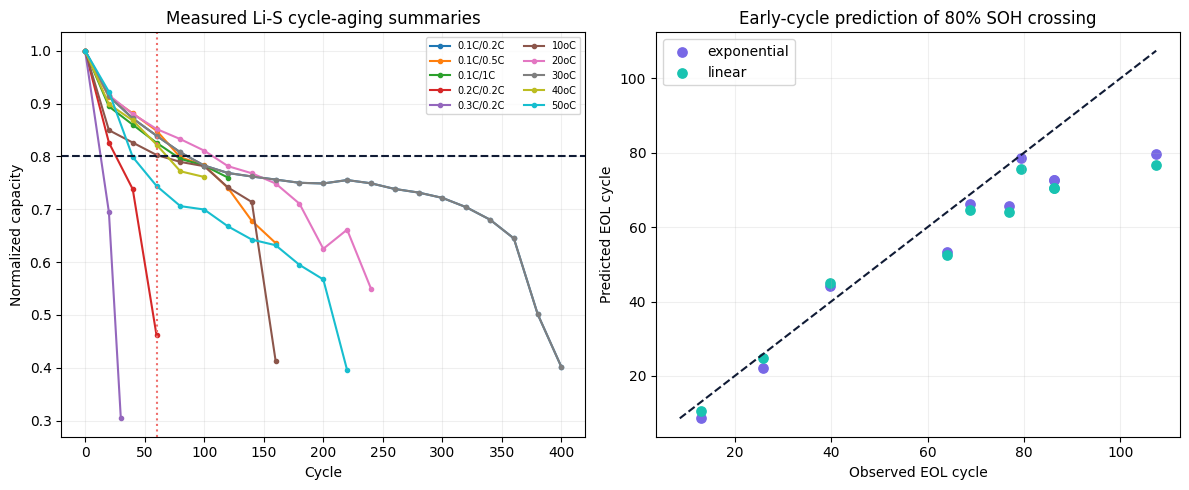

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
for name,g in d.groupby('condition'): ax[0].plot(g.cycle,g.soh,marker='o',ms=3,label=name)
ax[0].axhline(.8,ls='--',color='#101b35'); ax[0].axvline(60,ls=':',color='#ef6f6c'); ax[0].set(title='Measured Li-S cycle-aging summaries',xlabel='Cycle',ylabel='Normalized capacity'); ax[0].legend(ncol=2,fontsize=7)
o=r.dropna(subset=['absolute_error_cycles']); colors={'linear':'#19c3b1','exponential':'#7868e6'}
for method,g in o.groupby('method'): ax[1].scatter(g.observed_eol_cycle,g.predicted_eol_cycle,label=method,color=colors[method],s=45)
lo=min(o.observed_eol_cycle.min(),o.predicted_eol_cycle.min()); hi=max(o.observed_eol_cycle.max(),o.predicted_eol_cycle.max()); ax[1].plot([lo,hi],[lo,hi],'--',color='#101b35'); ax[1].set(title='Early-cycle prediction of 80% SOH crossing',xlabel='Observed EOL cycle',ylabel='Predicted EOL cycle'); ax[1].legend()
for a in ax:a.grid(alpha=.2)
fig.tight_layout(); fig.savefig(out/'cycle_rul_validation.png',dpi=180); plt.show()

## Validation boundary

The future portion of each condition trajectory is withheld from its early-cycle fit, so the benchmark is temporally held out. However, the public files contain condition-level means and error bars rather than separate raw cell identities. The ten curves also belong to one experimental program. This is stronger than the synthetic RUL screen, but it is not independent-campaign Level 2 validation and it does not validate conventional lithium-ion chemistry.